In [65]:
# Sales & Revenue Analysis

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [67]:
#1.Load Dataset

In [68]:
df =pd.read_excel(r"C:\Users\saiki\Desktop\Project1A\Project_sales\Sales_Data_Dirty_Practice.xlsx")

In [69]:
#Display first 5 rows 
print(df.head())

   Order Date   Product     Category  Quantity  Unit Price   Revenue   Region
0  2025-03-01  Keyboard  Electronics      14.0      554.02   7756.28    South
1  2025-03-01    Laptop  Electronics       9.0     1278.01  11502.09     East
2  2025-03-01     Phone  Electronics       2.0      306.94    613.88    North
3  2025-03-01  Keyboard  Electronics      17.0      551.48   9375.16  Central
4  2025-03-01       Pen          NaN      12.0      700.18   8402.16      NaN


In [70]:
#Basic information
print(df.info())
print("\n Shape of Dataset")
print(df.shape)
print("\n Column Names")
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order Date  505 non-null    object 
 1   Product     497 non-null    object 
 2   Category    497 non-null    object 
 3   Quantity    497 non-null    float64
 4   Unit Price  497 non-null    float64
 5   Revenue     510 non-null    float64
 6   Region      502 non-null    object 
dtypes: float64(3), object(4)
memory usage: 28.0+ KB
None

 Shape of Dataset
(510, 7)

 Column Names
Index(['Order Date', 'Product', 'Category', 'Quantity', 'Unit Price',
       'Revenue', 'Region'],
      dtype='object')


In [71]:
#3.Check Missing Values
print("\n Missing Values")
print(df.isnull().sum())


 Missing Values
Order Date     5
Product       13
Category      13
Quantity      13
Unit Price    13
Revenue        0
Region         8
dtype: int64


In [72]:
#4.Check Duplicates Rows
print("\n Duplicate Rows")
print(df.duplicated().sum())


 Duplicate Rows
9


In [73]:
#5.Remove Duplicates
df=df.drop_duplicates()

In [74]:
#6.Remove Extra Spaces
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df.loc[:,col]=df[col].str.strip()

In [75]:
#7.Convert Order Date to Determine 
if "Order Date" in df.columns:
    df.loc[:,"Order Date"]=pd.to_datetime(df["Order Date"],errors="coerce")

In [77]:
#8.Fill Missing Values
##Numerical Columns
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col].fillna(df[col].median())
##Categorical Columns
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0]).infer_objects(copy=False)

In [78]:
#9.Check Missing Values Again
print(df.isnull().sum())

Order Date     0
Product        0
Category       0
Quantity      13
Unit Price    13
Revenue        0
Region         0
dtype: int64


In [79]:
#10.Data Types
print(df.dtypes)

Order Date    datetime64[ns]
Product               object
Category              object
Quantity             float64
Unit Price           float64
Revenue              float64
Region                object
dtype: object


In [80]:
#11.Statistical Summary
print(df.describe())

                          Order Date    Quantity   Unit Price       Revenue
count                            501  488.000000   488.000000    501.000000
mean   2024-12-24 21:24:47.425149696   10.553279   995.475389  10557.191198
min              2024-01-01 00:00:00    1.000000     6.680000     57.000000
25%              2024-06-27 00:00:00    6.000000   480.677500   2799.720000
50%              2024-12-16 00:00:00   11.000000  1011.625000   8127.800000
75%              2025-06-25 00:00:00   15.000000  1450.672500  16531.920000
max              2025-12-30 00:00:00   20.000000  1996.250000  38662.800000
std                              NaN    5.583162   572.737515   9040.204187


In [81]:
#12.Save Clean Dataset
df.to_excel("Sales_Data_Cleaned.xlsx",index=False)

In [82]:
# Analysis

In [83]:
#Total Revenue
if "Revenue" in df.columns:
    print("Total Revenue:",df["Revenue"].sum())

Total Revenue: 5289152.789999999


In [84]:
#Average Revenue
if "Revenue" in df.columns:
    print("Average Revenue:",df["Revenue"].mean())

Average Revenue: 10557.191197604789


In [85]:
#Total Quantity 
if "Quantity" in df.columns:
    print("Total Quantity Sold:",df["Quantity"].sum())

Total Quantity Sold: 5150.0


In [86]:
# Region-wise Revenue
if "Region" in df.columns and "Revenue" in df.columns:
    print(df.groupby("Region")["Revenue"].sum())

Region
Central    1021202.31
East       1284053.59
North       891098.54
South      1038417.98
West       1054380.37
Name: Revenue, dtype: float64


In [87]:
# Category-wise Revenue
if "Category" in df.columns and "Revenue" in df.columns:
    print(df.groupby("Category")["Revenue"].sum())

Category
Electronics    2786890.41
Furniture      1026087.14
Office          455965.94
Stationery     1020209.30
Name: Revenue, dtype: float64


In [88]:
# Product-wise Quantity
if "Product" in df.columns and "Quantity" in df.columns:
    print(df.groupby("Product")["Quantity"].sum())

Product
Chair       448.0
Desk        563.0
Keyboard    635.0
Laptop      461.0
Monitor     486.0
Mouse       594.0
Notebook    569.0
Pen         464.0
Phone       458.0
Printer     472.0
Name: Quantity, dtype: float64


In [89]:
# VISUALIZATIONS (MATPLOTLIB)

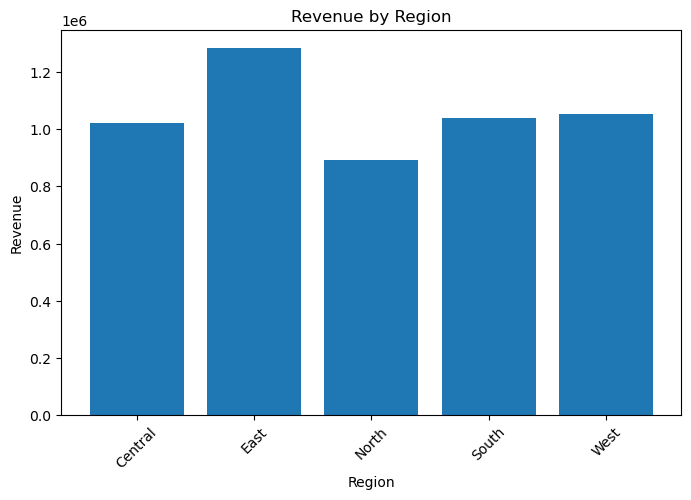

In [90]:
# --------------------------------------------
# 1. Revenue by Region
# --------------------------------------------

if "Region" in df.columns and "Revenue" in df.columns:

    revenue_region = df.groupby("Region")["Revenue"].sum()

    plt.figure(figsize=(8,5))
    plt.bar(revenue_region.index, revenue_region.values)
    plt.title("Revenue by Region")
    plt.xlabel("Region")
    plt.ylabel("Revenue")
    plt.xticks(rotation=45)
    plt.show()


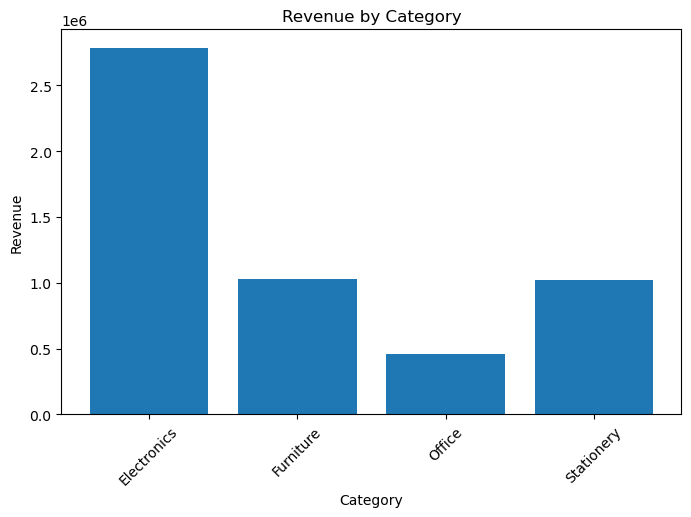

In [91]:
# --------------------------------------------
# 2. Revenue by Category
# --------------------------------------------

if "Category" in df.columns and "Revenue" in df.columns:

    revenue_category = df.groupby("Category")["Revenue"].sum()

    plt.figure(figsize=(8,5))
    plt.bar(revenue_category.index, revenue_category.values)
    plt.title("Revenue by Category")
    plt.xlabel("Category")
    plt.ylabel("Revenue")
    plt.xticks(rotation=45)
    plt.show()

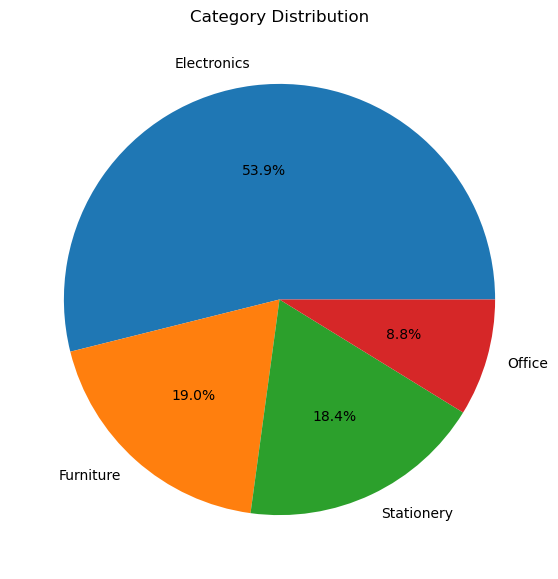

In [92]:
# --------------------------------------------
# 3. Category Distribution Pie Chart
# --------------------------------------------

if "Category" in df.columns:

    plt.figure(figsize=(7,7))
    df["Category"].value_counts().plot(
        kind="pie",
        autopct="%1.1f%%"
    )
    plt.title("Category Distribution")
    plt.ylabel("")
    plt.show()

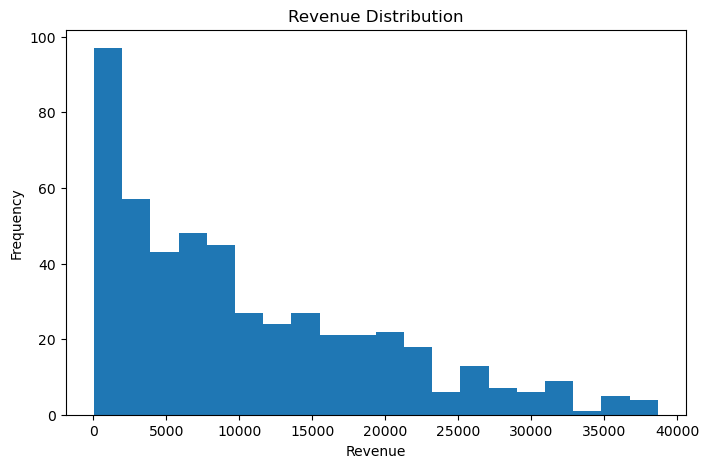

In [93]:
# --------------------------------------------
# 4. Revenue Distribution Histogram
# --------------------------------------------

if "Revenue" in df.columns:

    plt.figure(figsize=(8,5))
    plt.hist(df["Revenue"], bins=20)
    plt.title("Revenue Distribution")
    plt.xlabel("Revenue")
    plt.ylabel("Frequency")
    plt.show()

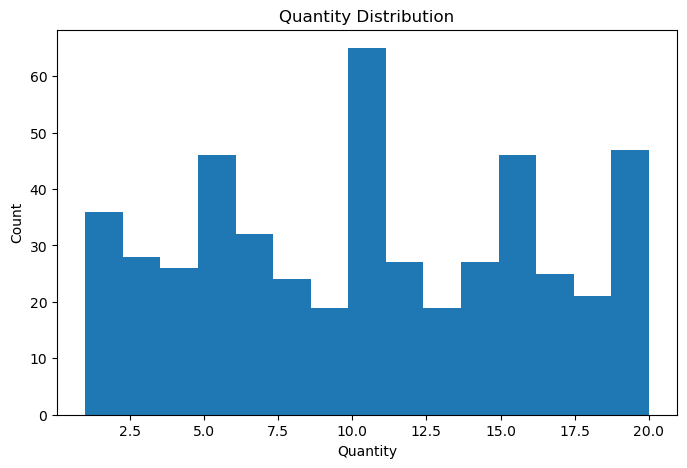

In [94]:
# --------------------------------------------
# 5. Quantity Distribution
# --------------------------------------------

if "Quantity" in df.columns:

    plt.figure(figsize=(8,5))
    plt.hist(df["Quantity"], bins=15)
    plt.title("Quantity Distribution")
    plt.xlabel("Quantity")
    plt.ylabel("Count")
    plt.show()

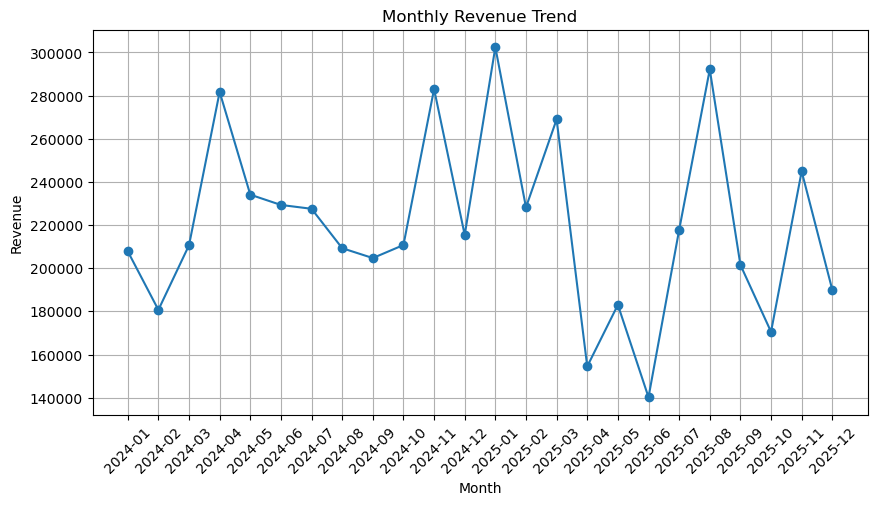

In [95]:
# --------------------------------------------
# 6. Monthly Revenue Trend
# --------------------------------------------

if "Order Date" in df.columns and "Revenue" in df.columns:

    monthly = df.groupby(df["Order Date"].dt.to_period("M"))["Revenue"].sum()

    plt.figure(figsize=(10,5))
    plt.plot(monthly.index.astype(str), monthly.values, marker='o')
    plt.title("Monthly Revenue Trend")
    plt.xlabel("Month")
    plt.ylabel("Revenue")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

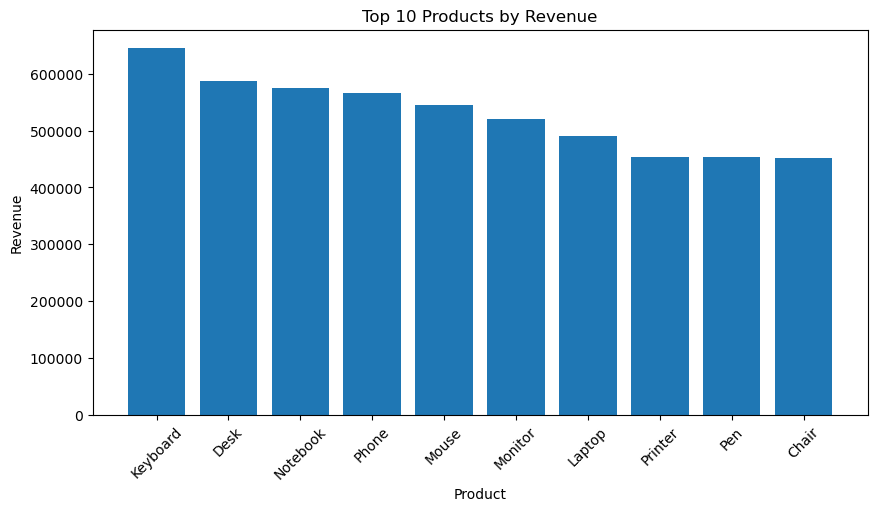

In [96]:
# --------------------------------------------
# 7. Top 10 Products by Revenue
# --------------------------------------------

if "Product" in df.columns and "Revenue" in df.columns:

    top_products = (
        df.groupby("Product")["Revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10,5))
    plt.bar(top_products.index, top_products.values)
    plt.title("Top 10 Products by Revenue")
    plt.xlabel("Product")
    plt.ylabel("Revenue")
    plt.xticks(rotation=45)
    plt.show()

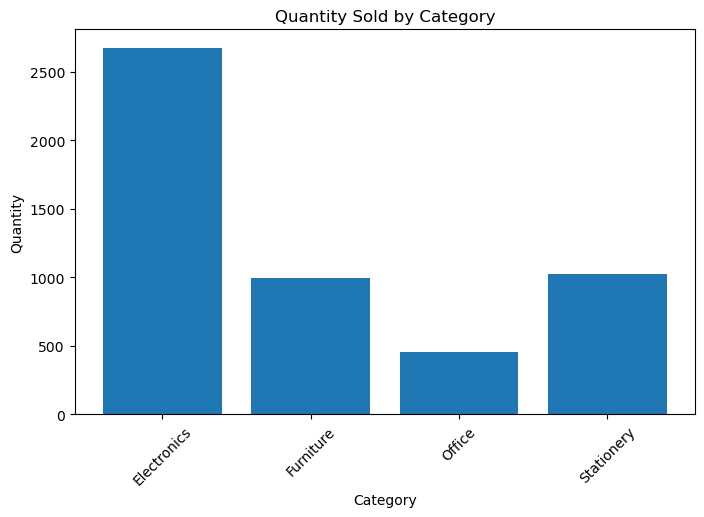

In [97]:
# --------------------------------------------
# 8. Quantity by Category
# --------------------------------------------

if "Category" in df.columns and "Quantity" in df.columns:

    qty = df.groupby("Category")["Quantity"].sum()

    plt.figure(figsize=(8,5))
    plt.bar(qty.index, qty.values)
    plt.title("Quantity Sold by Category")
    plt.xlabel("Category")
    plt.ylabel("Quantity")
    plt.xticks(rotation=45)
    plt.show()
